01:31:37 - cmdstanpy - INFO - Chain [1] start processing
01:31:40 - cmdstanpy - INFO - Chain [1] done processing


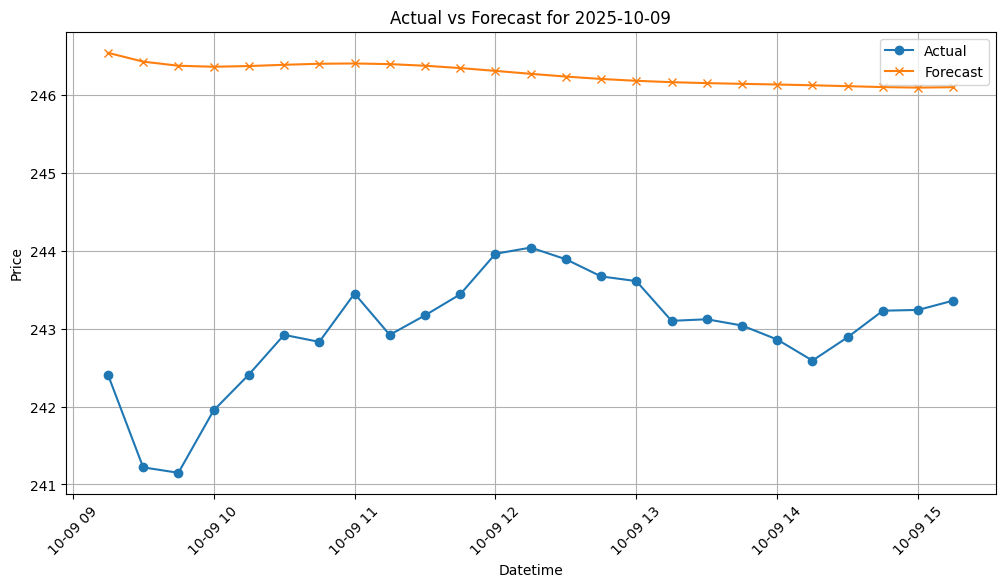

In [92]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from prophet import Prophet

# --- Load Data ---
def load_data(ticker, period):
    df = yf.Ticker(ticker).history(period=f"{period}d", interval="15m").reset_index()
    df['Datetime'] = pd.to_datetime(df['Datetime']).dt.tz_localize(None)
    return df

df = load_data('ONGC.NS', '60')

# --- Train & Test Split ---
df_train = df[(df['Datetime'] >= '2025-07-17 09:45:00') & (df['Datetime'] <= '2025-10-08 15:15:00')]
df_test = df[(df['Datetime'] >= '2025-10-09 09:15:00') & (df['Datetime'] <= '2025-10-09 15:15:00')]

# --- Prepare for Prophet ---
df_prophet = df_train[['Datetime','Close']].rename(columns={'Datetime':'ds','Close':'y'})

# --- Fit Prophet ---
m = Prophet()
m.fit(df_prophet)

# --- Future DataFrame (exact test timestamps) ---
future_df = pd.DataFrame({'ds': pd.date_range(start='2025-10-09 09:15:00',
                                              end='2025-10-09 15:15:00',
                                              freq='15min')})

# --- Forecast ---
forecast = m.predict(future_df)

# --- Merge actual & forecast ---
df_merged = df_test.merge(forecast[['ds','yhat']], left_on='Datetime', right_on='ds', how='left')

# --- Plot ---
plt.figure(figsize=(12,6))
plt.plot(df_merged['Datetime'], df_merged['Close'], label='Actual', marker='o')
plt.plot(df_merged['Datetime'], df_merged['yhat'], label='Forecast', marker='x')
plt.xlabel('Datetime')
plt.ylabel('Price')
plt.title('Actual vs Forecast for 2025-10-09')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
